# Fourier Neural Operator (FNO) in Neuromancer

This tutorial demonstrates the use of [FNOs](https://neuraloperator.github.io/dev/theory_guide/fno.html) for solving partial differential equations (PDEs) in the Neuromancer library.

Example inspiration: https://neuraloperator.github.io/dev/auto_examples/models/plot_FNO_darcy.html

<img src="https://neuraloperator.github.io/dev/_images/fourier_layer.jpg" width="600"> 

The Fourier layer just consists of three steps:
- Fourier transform $\mathcal{F}$
- Linear transform on the lower Fourier modes $\mathbf{R}$
- Inverse Fourier transform $\mathcal{F}^{-1}$


### References

<!-- [1] [Raissi, M., Perdikaris, P., & Karniadakis, G. E. (2017). Physics informed deep learning (part i): Data-driven solutions of nonlinear partial differential equations.](https://www.sciencedirect.com/science/article/abs/pii/S0021999118307125)

[2] https://github.com/jdtoscano94/Learning-Python-Physics-Informed-Machine-Learning-PINNs-DeepONets/tree/main

[3] https://github.com/omniscientoctopus/Physics-Informed-Neural-Networks/tree/main -->


## Install (Colab only)
Skip this step when running locally.

In [1]:
# !pip install neuromancer
# !pip install pyDOE

*Note: When running on Colab, one might encounter a pip dependency error with Lida 0.0.10. This can be ignored*

## Imports

In [2]:
# torch and numpy imports
import torch
import torch.nn as nn
import numpy as np

# plotting imports
import matplotlib.pyplot as plt

# filter some user warnings from torch broadcast
import warnings

warnings.filterwarnings("ignore")


In [3]:
# Set default dtype to float32
torch.set_default_dtype(torch.float)
# PyTorch random number generator
torch.manual_seed(1234)

# Random number generators in other libraries
np.random.seed(1234)

# Device configuration
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")


Using device: cuda


### Get data of the exact solution
- Data source: (https://zenodo.org/records/12784353)
- Select the number of training grids at a given resolution (16X16)
- Select the number of testing grids at various resolutions (16X16, 32x32)
- Save it in `./data/darcy_flow_small/`

In [4]:
from neuralop.data.datasets import DarcyDataset

dataset = DarcyDataset(
    root_dir="./data/darcy_flow_small/",
    n_train=20,
    n_tests=[10, 10],
    batch_size=4,
    test_batch_sizes=[4, 2],
    train_resolution=16,
    test_resolutions=[16, 32],
    download=True,
)

# train_dataset = dataset.train_dataset
print(dataset.__dict__.keys())  # check available keys in dataset

Loading test db for resolution 16 with 10 samples 
Loading test db for resolution 32 with 10 samples 
dict_keys(['root_dir', 'batch_size', 'test_resolutions', 'test_batch_sizes', '_train_db', '_data_processor', '_test_dbs'])


In [5]:
train_db = dataset._train_db
print((train_db.__dict__.keys()))  # check available keys in dataset
# Get dataset length and grid resolution
n_train = len(train_db)
index = 0
x_sample = train_db[index]["x"]  # shape (1, 16, 16) for your data
res_x, res_y = x_sample.shape[-2:]  # grid resolution

print(f"length of training set = {n_train}")
print(f"resolution = {res_x}")
print(f"shape of grid = [{res_x}, {res_y}]")


dict_keys(['x', 'y', 'transform_x', 'transform_y'])
length of training set = 20
resolution = 16
shape of grid = [16, 16]


Displaying sizes for the 32x32 testing grid

In [6]:
test_db = dataset._test_dbs[32]  # use 16,32 etc
print((test_db.__dict__.keys()))  # check available keys in dataset
# Get dataset length and grid resolution
n_train = len(test_db)

index = 0
x_sample = test_db[index]["x"]  # shape (1, 16, 16) for your data
res_x, res_y = x_sample.shape[-2:]  # grid resolution

print(f"length of training set = {n_train}")
print(f"resolution = {res_x}")
print(f"shape of grid = [{res_x}, {res_y}]")

dict_keys(['x', 'y', 'transform_x', 'transform_y'])
length of training set = 10
resolution = 32
shape of grid = [32, 32]


### Visualise dataset
We can see how the positional embedding adds coordinate information to our input data. This helps the neural operator understand spatial relationships in the data.
Not necessarly need to use this for the input grid

In [7]:
from neuralop.layers.embeddings import GridEmbedding2D

# Which sample to view
index = 0

data = train_db[index]
data = dataset.data_processor.preprocess(data, batched=False)

# The first step of the default FNO model is a grid-based
# positional embedding. We will add it manually here to
# visualize the channels appended by this embedding.
positional_embedding = GridEmbedding2D(in_channels=1)
# At train time, data will be collated with a batch dimension.
# We create a batch dimension to pass into the embedding, then re-squeeze
x = positional_embedding(data["x"].unsqueeze(0)).squeeze(0)
y = data["y"]

/tmp/ipykernel_236090/2254824060.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


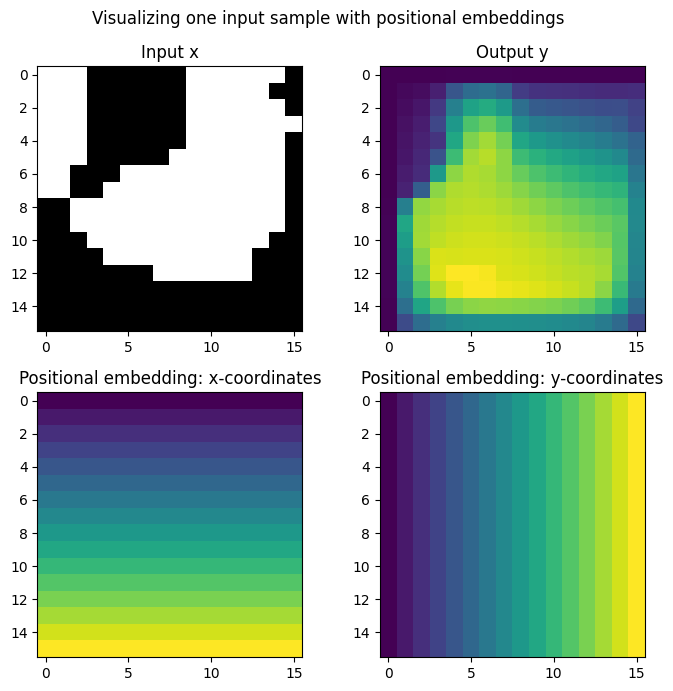

In [8]:
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(2, 2, 1)
ax.imshow(x[0], cmap="gray")
ax.set_title("Input x")
ax = fig.add_subplot(2, 2, 2)
ax.imshow(y.squeeze())
ax.set_title("Output y")
ax = fig.add_subplot(2, 2, 3)
ax.imshow(x[1])
ax.set_title("Positional embedding: x-coordinates")
ax = fig.add_subplot(2, 2, 4)
ax.imshow(x[2])
ax.set_title("Positional embedding: y-coordinates")
fig.suptitle("Visualizing one input sample with positional embeddings", y=0.98)
plt.tight_layout()
fig.show()

### Create Neuromancer datasets for FNO

In [9]:
from neuromancer.dataset import DictDataset

batch_size_train = 4

# Stack the samples (apply the same preprocessing if you need it)
xs, ys = [], []
for i in range(len(dataset._train_db)):
    sample = dataset.data_processor.preprocess(dataset._train_db[i], batched=False)
    xs.append(sample["x"])
    ys.append(sample["y"])
x_train = torch.stack(xs)  # [N, 1, 16, 16]
y_train = torch.stack(ys)

# send to device
x_train = x_train.to(device)
y_train = y_train.to(device)
# turn on gradients for FNO
x_train.requires_grad = True
y_train.requires_grad = True

train_ds_fno = DictDataset({"x_grid": x_train, "y_grid": y_train}, name="train")
train_loader_fno = torch.utils.data.DataLoader(
    train_ds_fno,
    batch_size=batch_size_train,
    shuffle=True,
    collate_fn=train_ds_fno.collate_fn,
)

# Example test loader (pick one resolution index)
res = 32  # 16 or 32
batch_size_test = 4
xs_t, ys_t = [], []
for i in range(len(dataset.test_dbs[res])):
    sample = dataset.data_processor.preprocess(dataset.test_dbs[res][i], batched=False)
    xs_t.append(sample["x"])
    ys_t.append(sample["y"])
test_ds_fno = DictDataset(
    {"x_grid": torch.stack(xs_t), "y_grid": torch.stack(ys_t)}, name=f"test{res}"
)
test_loader_fno = torch.utils.data.DataLoader(
    test_ds_fno,
    batch_size=batch_size_test,  # match your test batch size
    shuffle=False,
    collate_fn=test_ds_fno.collate_fn,
)

### FNO added from neuralop library
May need a wrapper to provide data in the correct format


In [ ]:
# wrapper for neuralop.models import FNO
from neuromancer.modules.operators import FNO
from neuralop.utils import count_model_params
import sys

# FNO to to train the operator for the PDE problem bounded in the PDE domain
fno_model = FNO(
    n_modes=(8, 8),
    in_channels=1,
    out_channels=1,
    hidden_channels=12,
    projection_channel_ratio=2,
)
fno_model = fno_model.to(device)

# Count and display the number of parameters
n_params = count_model_params(fno_model)
print(f"\nOur model has {n_params} parameters.")
sys.stdout.flush()


Our model has 48133 parameters.


In [13]:
from neuromancer.system import Node

# symbolic wrapper of the FNO
fno_node = Node(fno_model, ["x_grid"], ["y_fno"], name="fno_model")

In [14]:
print("symbolic inputs  of the fno_node:", fno_node.input_keys)
print("symbolic outputs of the fno_node:", fno_node.output_keys)

symbolic inputs  of the fno_node: ['x_grid']
symbolic outputs of the fno_node: ['y_fno']


In [15]:
# check device
print(train_ds_fno.datadict["y_grid"].device)
# evaluate forward pass on the train data
fno_model_out = fno_node(train_ds_fno.datadict)
fno_model_out["y_fno"].shape

cuda:0


torch.Size([20, 1, 16, 16])

### Generate H1 and L2 loss for loss evaluation 
We use H1 loss for training and L2 loss for evaluation H1 loss is particularly good for PDE problems as it penalizes both function values and gradients

## L2 norm

$$
\|y - y_h\|_{L^2(\Omega)}^2.
$$

In [16]:
from neuromancer.constraint import Objective, variable

# define L2 loss objective for FNO
y_true = variable("y_grid")  # ground-truth field in your datadict
y_fno = variable("y_fno")  # output from the FNO node

In [17]:
# Approach 1: Using Constraint from Variables
l2_constraint = (y_fno == y_true) ^ 2  # Eq constraint with quadratic penalty
l2_constraint.key = "l2norm"

In [18]:
# Approach 2: Using Objective
residual = y_fno - y_true
l2_obj = Objective(residual**2, metric=torch.mean, name="l2_loss")

## H1 norm (not working for now)

$$
\|y - y_h\|_{H^1(\Omega)}^2
=
\|y - y_h\|_{L^2(\Omega)}^2
+
\|y_x - y_{h,x}\|_{L^2(\Omega)}^2
+
\|y_t - y_{h,t}\|_{L^2(\Omega)}^2.
$$

In [19]:
# define H1 loss objective for FNO
x = variable("x_grid")
# H^1-style constraint: penalize the field mismatch plus spatial/temporal gradients
grad_y_hat_x = y_fno.grad(x)
grad_y_true_x = y_true.grad(x)

In [20]:
# Approach 1: Using Constraint from Variables
# Derivative L2 error in x (seminorm)
x_seminorm = (grad_y_hat_x == grad_y_true_x) ^ 2
x_seminorm.key = "h1_x_seminorm"

In [21]:
# Approach 2: Using Objective
# Derivative residuals in x and t
res_grad_y_hat_x = grad_y_hat_x - grad_y_true_x
# res_grad_y_hat_t = grad_y_hat_t - grad_y_true_t
h1_residual = residual**2 + res_grad_y_hat_x**2
h1_obj = Objective(h1_residual, metric=torch.mean, name="h1_loss")

### Setup H1 loss from neuralop ((not working for now))

In [22]:
from neuralop import H1Loss

# setup H1 loss from neuralop
h1loss = H1Loss(d=2, reduction="mean")  # set other kwargs (h, periodic) if needed

# bridge neuralop loss to neuromancer objective
# h1_obj = Objective(
#     lambda d: h1loss(d["y_fno"], d["y_grid"]),  # preds vs targets
#     name="h1",
# )

### Setup FNO problem and Trainer 

In [23]:
from neuromancer.loss import PenaltyLoss
from neuromancer.problem import Problem

# aggregate list of objective terms and constraints
# objectives_fno = [l2_constraint, x_seminorm]  # H1 loss for training FNO
objectives_fno = [l2_obj]  # L2 loss for training FNO
constraints_fno = []
# create constrained optimization loss
loss_fno = PenaltyLoss(objectives_fno, constraints_fno)

# construct the FNO supervised training problem
problem_fno = Problem(nodes=[fno_node], loss=loss_fno)

### Show problem FNO

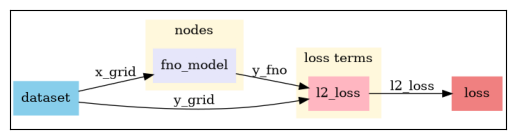

In [24]:
# Visualize the problem graph. Note: must have graphviz installed in the system
problem_fno.show()

### Train FNO pirely data driven

In [25]:
from neuromancer.trainer import Trainer

optimizer = torch.optim.AdamW(problem_fno.parameters(), lr=1e-2, weight_decay=1e-4)
epochs = 50

#  Neuromancer trainer
trainer = Trainer(
    problem_fno.to(device),
    train_loader_fno,
    optimizer=optimizer,
    epochs=epochs,
    epoch_verbose=5,
    train_metric="train_loss",
    dev_metric="train_loss",
    eval_metric="train_loss",
    warmup=epochs,
    device=device,
)

In [26]:
# Train FNO
best_model = trainer.train()

# load best trained model
problem_fno.load_state_dict(best_model)

epoch: 0  train_loss: 1.0187387466430664
epoch: 5  train_loss: 0.6213456988334656
epoch: 10  train_loss: 0.546280562877655
epoch: 15  train_loss: 0.5375041365623474
epoch: 20  train_loss: 0.5633243322372437
epoch: 25  train_loss: 0.527214527130127
epoch: 30  train_loss: 0.5275391936302185
epoch: 35  train_loss: 0.5279938578605652
epoch: 40  train_loss: 0.5181636214256287
epoch: 45  train_loss: 0.5341424942016602


<All keys matched successfully>

## Plots

In [27]:
# evaluate trained FNO on test data
fno_out = problem_fno.nodes[0].cpu()
fno_model_out = fno_out(test_ds_fno.datadict)

# evaluate forward pass on the train data
fno_model_out["y_fno"].shape

torch.Size([10, 1, 32, 32])

/tmp/ipykernel_236090/32698566.py:36: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


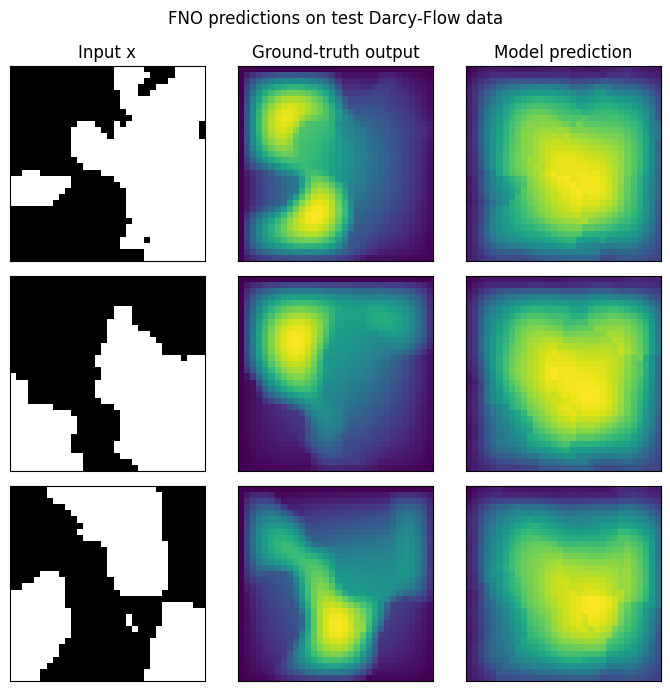

In [28]:
# Get predictions from the trained FNO on the stacked test set
fno_eval = problem_fno.nodes[0].cpu()  # ensure model on CPU for plotting
with torch.no_grad():
    preds = fno_eval(test_ds_fno.datadict)["y_fno"].cpu()

fig = plt.figure(figsize=(7, 7))
for index in range(3):
    sample = test_ds_fno[index]  # {'x_grid': ..., 'y_grid': ...}
    x = sample["x_grid"].cpu()
    y = sample["y_grid"].cpu()
    out = preds[index]  # model output from problem_fno

    ax = fig.add_subplot(3, 3, index * 3 + 1)
    ax.imshow(x[0], cmap="gray")
    if index == 0:
        ax.set_title("Input x")
    plt.xticks([], [])
    plt.yticks([], [])

    ax = fig.add_subplot(3, 3, index * 3 + 2)
    ax.imshow(y.squeeze())
    if index == 0:
        ax.set_title("Ground-truth output")
    plt.xticks([], [])
    plt.yticks([], [])

    ax = fig.add_subplot(3, 3, index * 3 + 3)
    ax.imshow(out.squeeze().detach().numpy())
    if index == 0:
        ax.set_title("Model prediction")
    plt.xticks([], [])
    plt.yticks([], [])

fig.suptitle("FNO predictions on test Darcy-Flow data", y=0.98)
plt.tight_layout()
fig.show()
